# Statistical Tests

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, anderson_ksamp

from src.spatial import vsini_maps_for_plane

from src.statistics import (
    monte_carlo_permutation,
    monte_carlo_stratified_teff,
    scan_cavity_significance,
    morans_I,
)
from src.plotting import (
    plot_vsini_bootstrap_panel,
    plot_significance_maps,
    plot_permutation_result,
    plot_radial_scan,
    plot_morans_I,
    plot_vsini_distance,
    plot_teff_strata_boxplots,
    plot_residual_decomposition
)

from src.style import setup_style

setup_style(fontsize=12)

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
COLORS = {
    "F": "#2166ac",
    "G": "#d68d4d",
    "ALL": "#404040",
}

ROOT = Path("../")
FIG_DIR = ROOT / "figures"
R_CUT = 80.0
SEED = 42

## 2. Load data

In [4]:
df_F = pd.read_csv(ROOT / "data" / "processed" / "gcs-Fstars-complete.csv")
df_G = pd.read_csv(ROOT / "data" / "processed" / "gcs-Gstars-complete.csv")
df_all = pd.read_csv(ROOT / "data" / "processed" / "gcs-allstars-complete.csv")

print(f"F: {len(df_F):,}  G: {len(df_G):,}  Total: {len(df_all):,}")

n_in = (df_all["R_xy"] <= R_CUT).sum()
n_out = (df_all["R_xy"] > R_CUT).sum()
print(f"\nCavity (R <= {R_CUT:.0f} pc) : {n_in:,} stars")
print(f"Shell  (R >  {R_CUT:.0f} pc) : {n_out:,} stars")

F: 1,475  G: 1,298  Total: 2,773

Cavity (R <= 80 pc) : 2,440 stars
Shell  (R >  80 pc) : 333 stars


## 3. Teff comparison: cavity vs. shell

In [5]:
mask_in = df_all["R_xy"] <= R_CUT
mask_out = df_all["R_xy"] > R_CUT
teff_in = df_all.loc[mask_in, "Teff"].dropna().values
teff_out = df_all.loc[mask_out, "Teff"].dropna().values

ks_stat, ks_p = ks_2samp(teff_in, teff_out)
ad_res = anderson_ksamp([teff_in, teff_out])
ad_stat = ad_res.statistic

print(f"Inner cavity  N={len(teff_in):,}  mean Teff = {teff_in.mean():.0f} K")
print(f"Outer shell   N={len(teff_out):,}   mean Teff = {teff_out.mean():.0f} K")
print(f"KS stat = {ks_stat:.4f}  p = {ks_p:.2e}")
print(f"AD stat = {ad_stat:.4f}")

Inner cavity  N=2,440  mean Teff = 6022 K
Outer shell   N=333   mean Teff = 6371 K
KS stat = 0.3248  p = 5.82e-28
AD stat = 136.6921


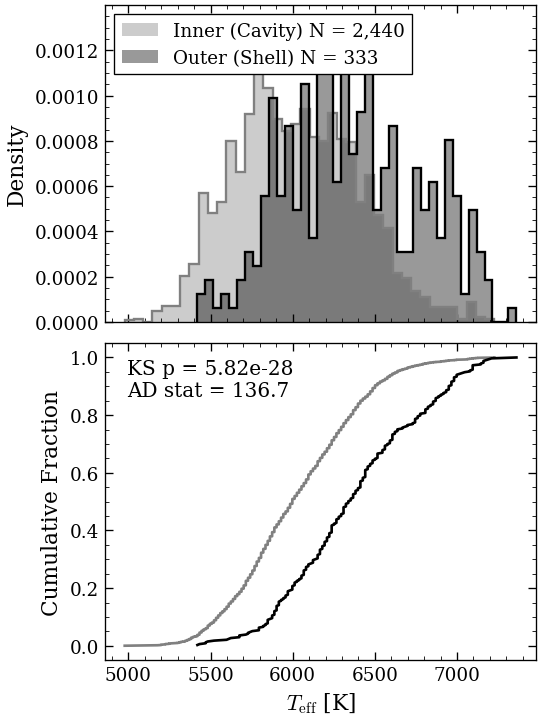

In [6]:
fig_teff, axes_teff = plt.subplots(2, 1, figsize=(4.5, 6), sharex=True)

plot_data = [
    (f"Inner (Cavity) N = {len(teff_in):,}", teff_in, "gray", "gray"),
    (f"Outer (Shell) N = {len(teff_out):,}", teff_out, "black", "black"),
]

# Histogram
ax = axes_teff[0]
for lbl, teff, fc, _ in plot_data:
    ax.hist(
        teff,
        bins=40,
        color=fc,
        alpha=0.4,
        density=True,
        histtype="stepfilled",
        label=lbl,
    )
    ax.hist(teff, bins=40, color=fc, density=True, histtype="step", lw=1.4)
ax.set_ylabel("Density")
ax.legend(loc="upper left")

# ECDF
ax = axes_teff[1]
for lbl, teff, _, lc in plot_data:
    t_sorted = np.sort(teff)
    ecdf = np.arange(1, len(t_sorted) + 1) / len(t_sorted)
    ax.plot(t_sorted, ecdf, color=lc, lw=1.6, label=lbl)
ax.set_xlabel(r"$T_{\rm eff}$ [K]")
ax.set_ylabel("Cumulative Fraction")
# ax.legend()
ax.text(
    0.05,
    0.95,
    f"KS p = {ks_p:.2e}\nAD stat = {ad_stat:.1f}",
    transform=ax.transAxes,
    va="top",
)

# fig_teff.savefig(FIG_DIR / "teff_cavity_shell_full.pdf")
plt.show()

## 4. Global Monte Carlo permutation test

In [7]:
res_mc_all = monte_carlo_permutation(df_all, iterations=10_000, r_cut=R_CUT, seed=SEED)

print("--- Global permutation (all stars) ---\n")
print(f"  Observed Delta⟨vsini⟩: {res_mc_all['obs_diff']:.3f} km/s")
print(f"  p-value: {res_mc_all['p_value']}")
print(f"  Z-score: {res_mc_all['z_score']:.2f} sigma")

--- Global permutation (all stars) ---

  Observed Delta⟨vsini⟩: 13.460 km/s
  p-value: 0.0
  Z-score: 12.81 sigma


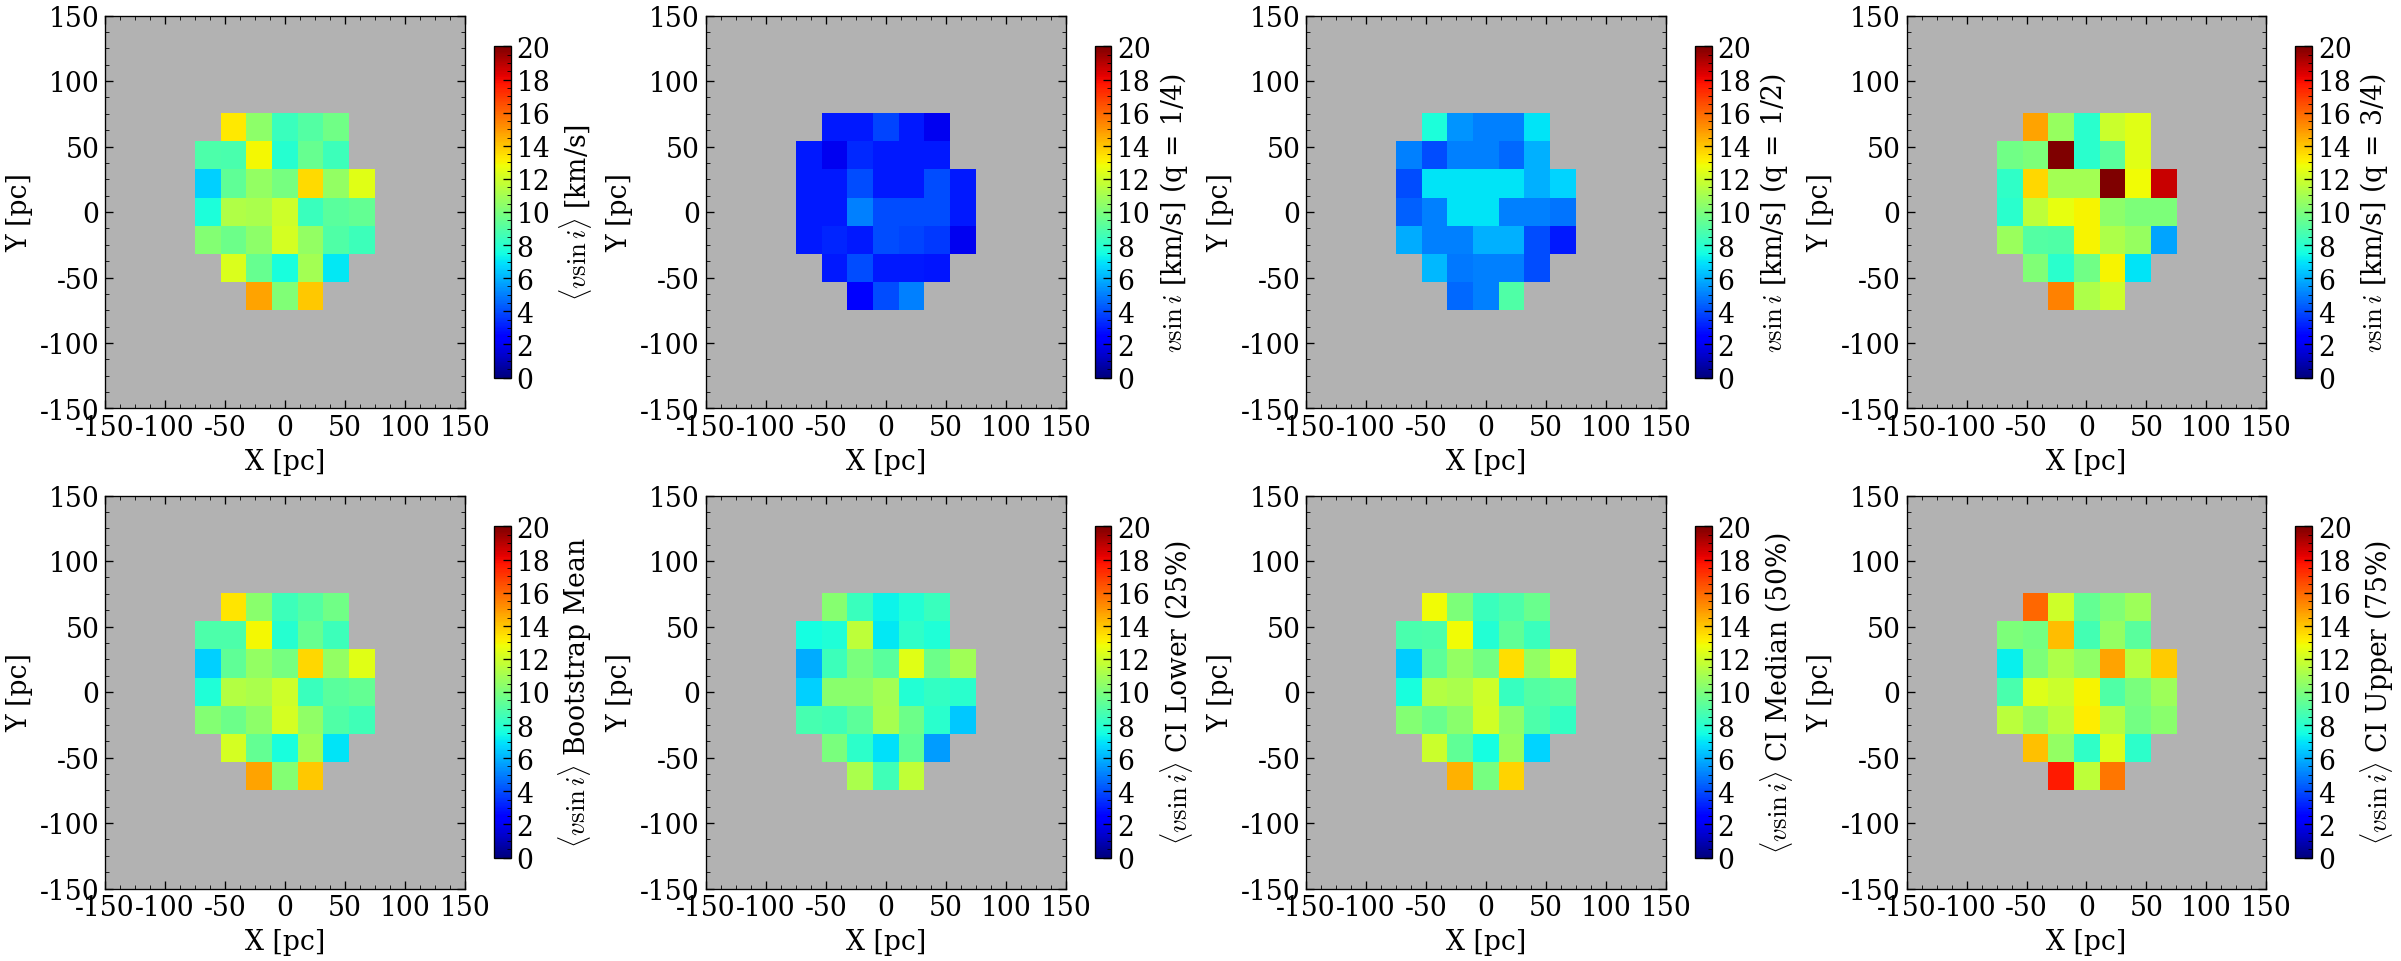

In [8]:
rng = np.random.default_rng(SEED + 1)
df_perm_all = df_all.copy()
df_perm_all["vsini"] = rng.permutation(df_all["vsini"].to_numpy())
# df_perm_F = df_perm_all[df_perm_all["SpecType"].str.startswith("F", na=False)].copy()
# df_perm_G = df_perm_all[df_perm_all["SpecType"].str.startswith("G", na=False)].copy()

UL = 150
TC = 20
N_BOOT = 1000

maps_all_XY = vsini_maps_for_plane(
    df_perm_all, "XY", ul=UL, tc=TC, n_bootstrap=N_BOOT, seed=SEED, use_weights=True
)

fig, _ = plot_vsini_bootstrap_panel(
    original=maps_all_XY["original"],
    bootstrap=maps_all_XY["bootstrap"],
    plane="XY",
    ul=UL,
    method="spline16",
    cmap="jet",
    vmax=20,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
# fig.savefig(FIG_DIR / "vsini_all_XY_permutation.pdf")
plt.show()

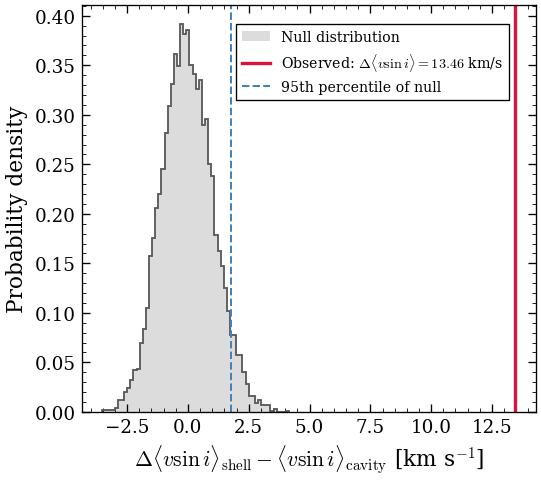

In [10]:
fig, ax = plot_permutation_result(
    res_mc_all["null_dist"], res_mc_all["obs_diff"], figsize=(4.5, 4)
)
# fig.savefig(FIG_DIR / "permutation_global.pdf")
plt.show()

## 5. Stratified permutation test

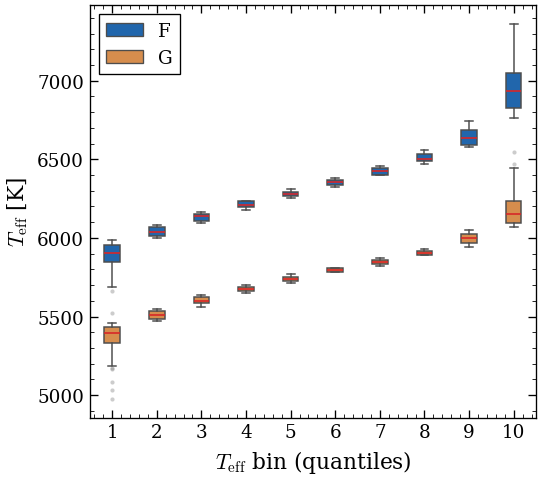

In [11]:
fig, ax = plt.subplots(figsize=(4.5, 4))

fig, ax, h1 = plot_teff_strata_boxplots(
    df_F, n_bins=10, ax=ax, color=COLORS["F"], type_label="F"
)

fig, ax, h2 = plot_teff_strata_boxplots(
    df_G, n_bins=10, ax=ax, color=COLORS["G"], type_label="G"
)

ax.legend(handles=[h1, h2])
plt.show()

In [12]:
res_strat_all = monte_carlo_stratified_teff(
    df_all, iterations=10_000, r_cut=R_CUT, n_bins=10, seed=SEED
)

print("--- Stratified permutation (all stars) ---\n")
print(f"  Observed Δ⟨vsini⟩: {res_strat_all['obs_diff']:.3f} km/s")
print(f"  p-value: {res_strat_all['p_value']:.4f}")
print(f"  Z-score: {res_strat_all['z_score']:.2f} sigma")

--- Stratified permutation (all stars) ---

  Observed Δ⟨vsini⟩: 13.460 km/s
  p-value: 0.0007
  Z-score: 3.18 sigma


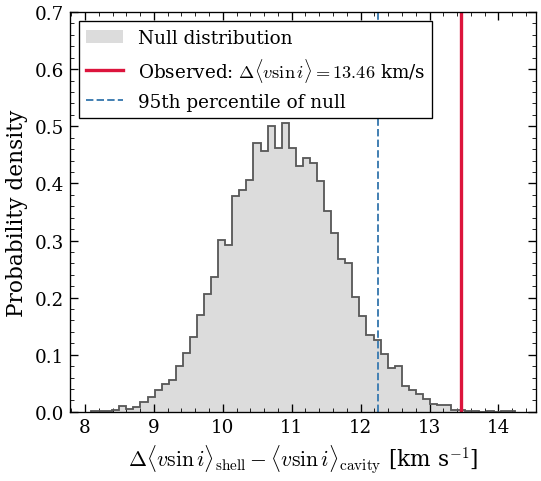

In [13]:
fig, ax = plot_permutation_result(
    res_strat_all["null_dist"],
    res_strat_all["obs_diff"],
    figsize=(4.5, 4),
)
ax.legend(loc="upper left")
ax.set_ylim(0, 0.7)
# fig.savefig(FIG_DIR / "fig_permutation_stratified.pdf")
plt.show()

## 6. Cavity radius scan

In [14]:
radii_scan = np.arange(40, 135, 5, dtype=float)
df_scan = scan_cavity_significance(
    df_all, radii=radii_scan, iterations=500, n_bins=10, seed=SEED
)
df_scan

,Radius,N_in,N_out,Observed,Expected,Uncertainty,Z_score,p_value
0,40.0,1176,1597,4.350013,4.685624,0.215685,-1.556025,0.934
1,45.0,1404,1369,5.351145,5.579159,0.262230,-0.869521,0.790
2,50.0,1632,1141,5.561014,5.988603,0.271473,-1.575074,0.948
3,55.0,1809,964,6.857415,7.206083,0.362553,-0.961702,0.838
4,60.0,1985,788,8.028651,7.870371,0.417499,0.379114,0.360
5,65.0,2130,643,9.114146,7.982247,0.474432,2.385797,0.018
6,70.0,2256,517,10.753337,9.144376,0.539227,2.983829,0.002
7,75.0,2344,429,12.565714,10.296657,0.658062,3.448092,0.002
8,80.0,2440,333,13.459746,10.910559,0.772102,3.301616,0.000
9,85.0,2513,260,15.298160,11.270174,0.898772,4.481658,0.000


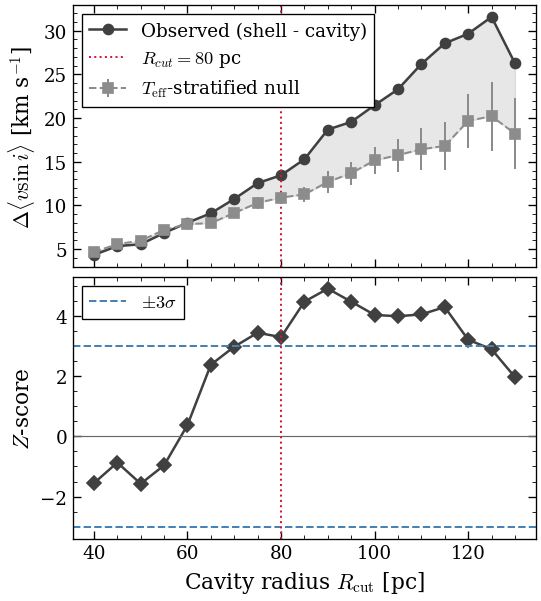

In [15]:
fig, axes = plot_radial_scan(df_scan, r_cut=R_CUT, figsize=(4.5, 5))
# fig.savefig(FIG_DIR / "radial_scan.pdf")
plt.show()

## 7. Statistical significance (Z-score) maps

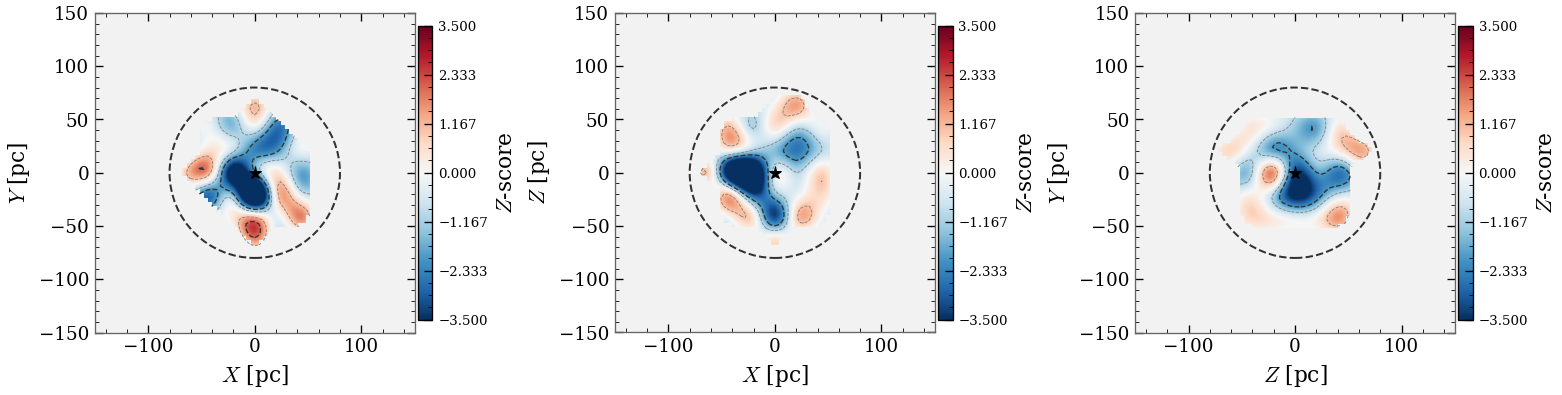

In [16]:
# F-type
fig_sig_F, _ = plot_significance_maps(
    df_F,
    ul=150,
    tc=20,
    # raw_cells=True,
    # view_limit = 150,
    # nan_color='0.7',
    # tick_step=50
)
# fig_sig_F.savefig(FIG_DIR / "fig_significance_F.pdf")
plt.show()

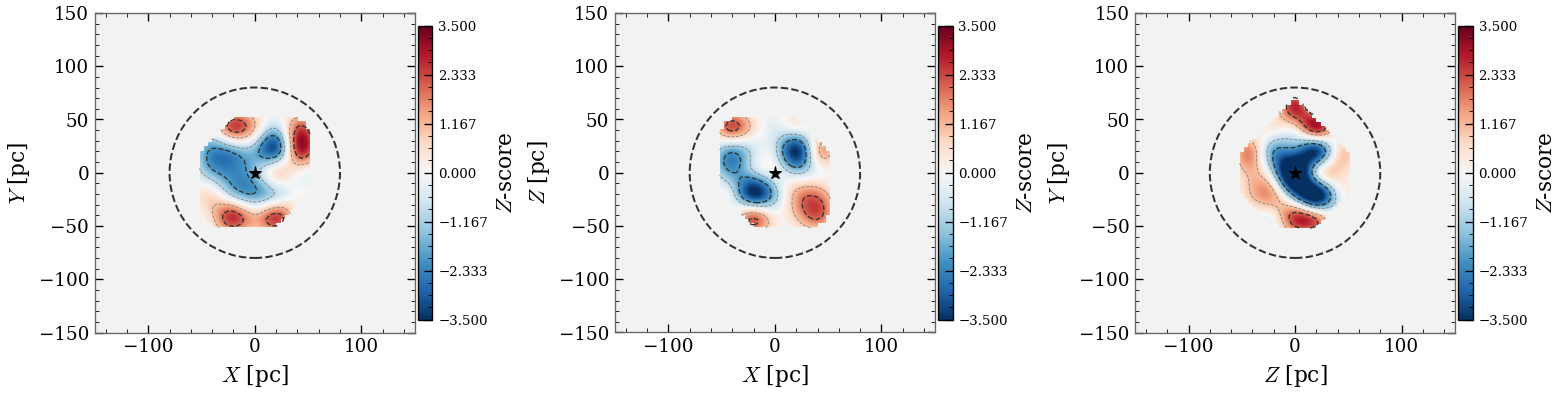

In [17]:
# G-type
fig_sig_G, _ = plot_significance_maps(df_G, ul=150, tc=20)
# fig_sig_G.savefig(FIG_DIR / "fig_significance_G.pdf")
plt.show()

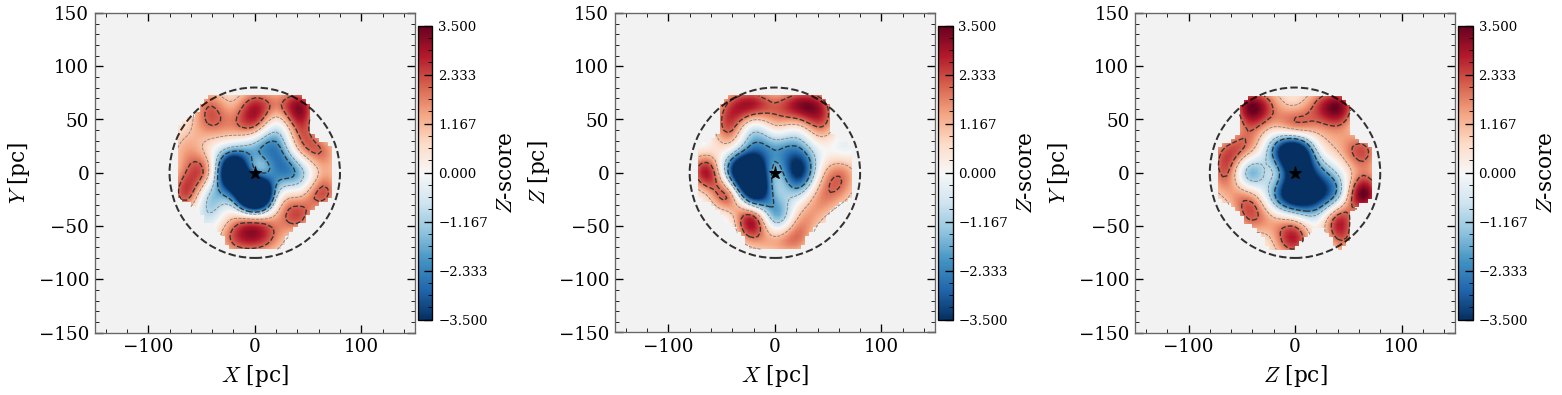

In [18]:
# ALL type
fig_sig_all, _ = plot_significance_maps(df_all, ul=150, tc=20)
# fig_sig_all.savefig(FIG_DIR / "fig_significance_all.pdf")
plt.show()

## 7b. Residual maps

In [19]:
from src.statistics_p5 import compute_residual_maps
from src.plotting_p6 import plot_residual_maps

print("Computing residual maps (N_MC=10 000)")
residual_maps_all = compute_residual_maps(
    df_all,
    planes=("XY", "XZ", "ZY"),
    ul=150.0,
    tc=20.0,
    n_mc=10_000,
    n_bins=10,
    min_count=20,
    seed=SEED,
)
print("Done.")

# Quick summary of the residual signal
for plane in ("XY", "XZ", "ZY"):
    res = residual_maps_all[plane]["residual"]
    print(
        f"  {plane}: residual range [{np.nanmin(res):.2f}, {np.nanmax(res):.2f}] km/s  "
        f"  |median| = {np.nanmedian(np.abs(res)):.2f} km/s"
    )

Computing residual maps (N_MC=10 000)
Done.
  XY: residual range [-6.79, 0.62] km/s    |median| = 0.67 km/s
  XZ: residual range [-3.66, 3.96] km/s    |median| = 0.75 km/s
  ZY: residual range [-5.01, 1.12] km/s    |median| = 0.71 km/s


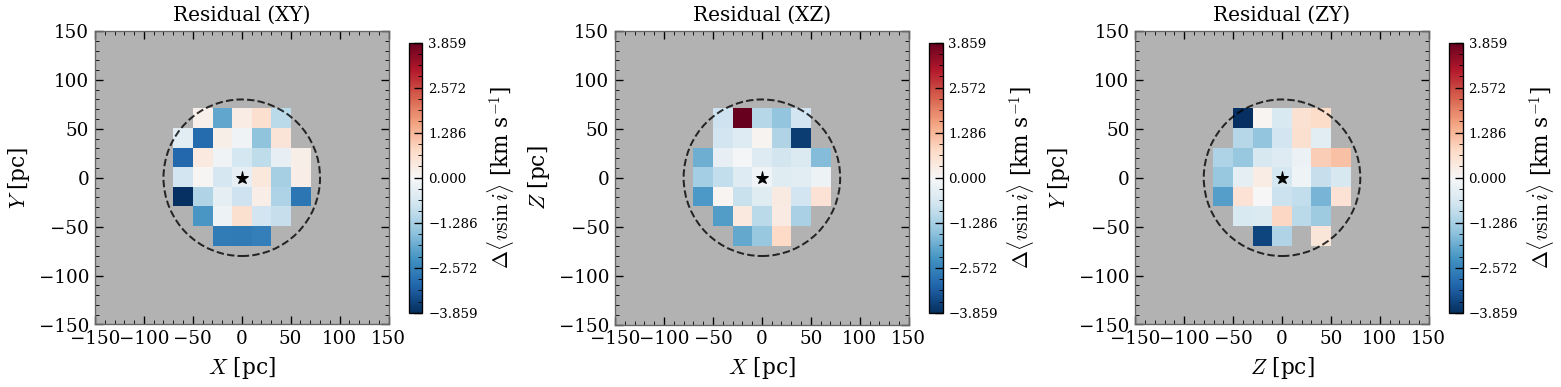

In [20]:
fig_res, axes_res = plot_residual_maps(
    residual_maps_all,
    ul=150.0,
    r_cut=R_CUT,
    raw_cells=True,
    view_limit = 150,
    nan_color='0.7',
    tick_step=50
)
fig_res.savefig(FIG_DIR / "residual_maps.pdf")
plt.show()

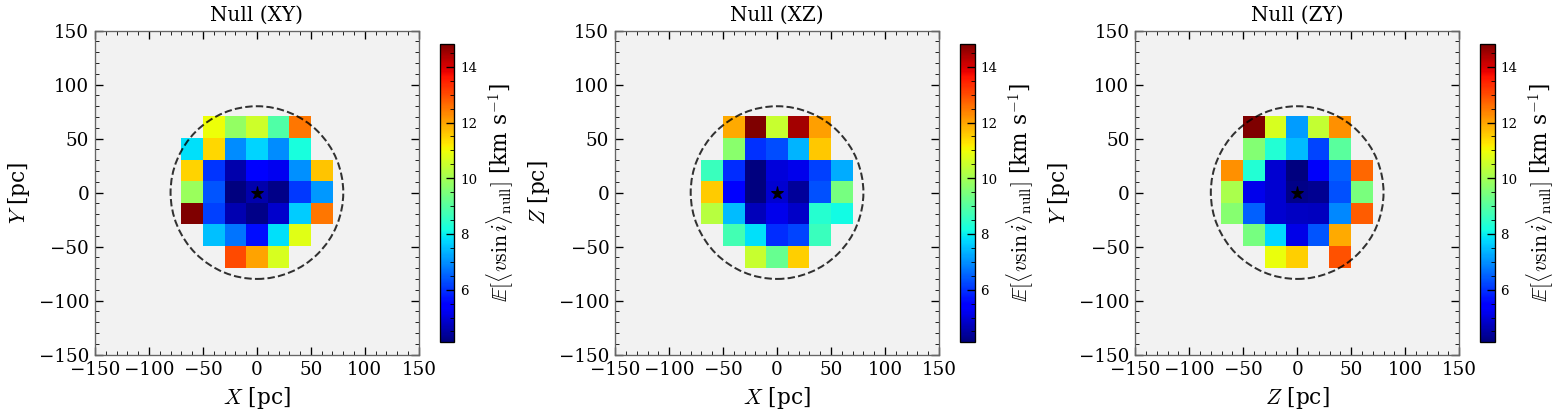

In [21]:
# Referee Major Comment 3: show the Teff-stratified null (expected) field that
# is being subtracted, so readers can see what spatial structure is removed.
fig_null, axes_null = plot_residual_maps(
    residual_maps_all,
    ul=150.0,
    r_cut=R_CUT,
    field="expected",
    cmap="jet",
    title_prefix="Null",
    view_limit=150,
    tick_step=50,
    raw_cells=True
)
fig_null.savefig(FIG_DIR / "null_expected_maps.pdf")
plt.show()

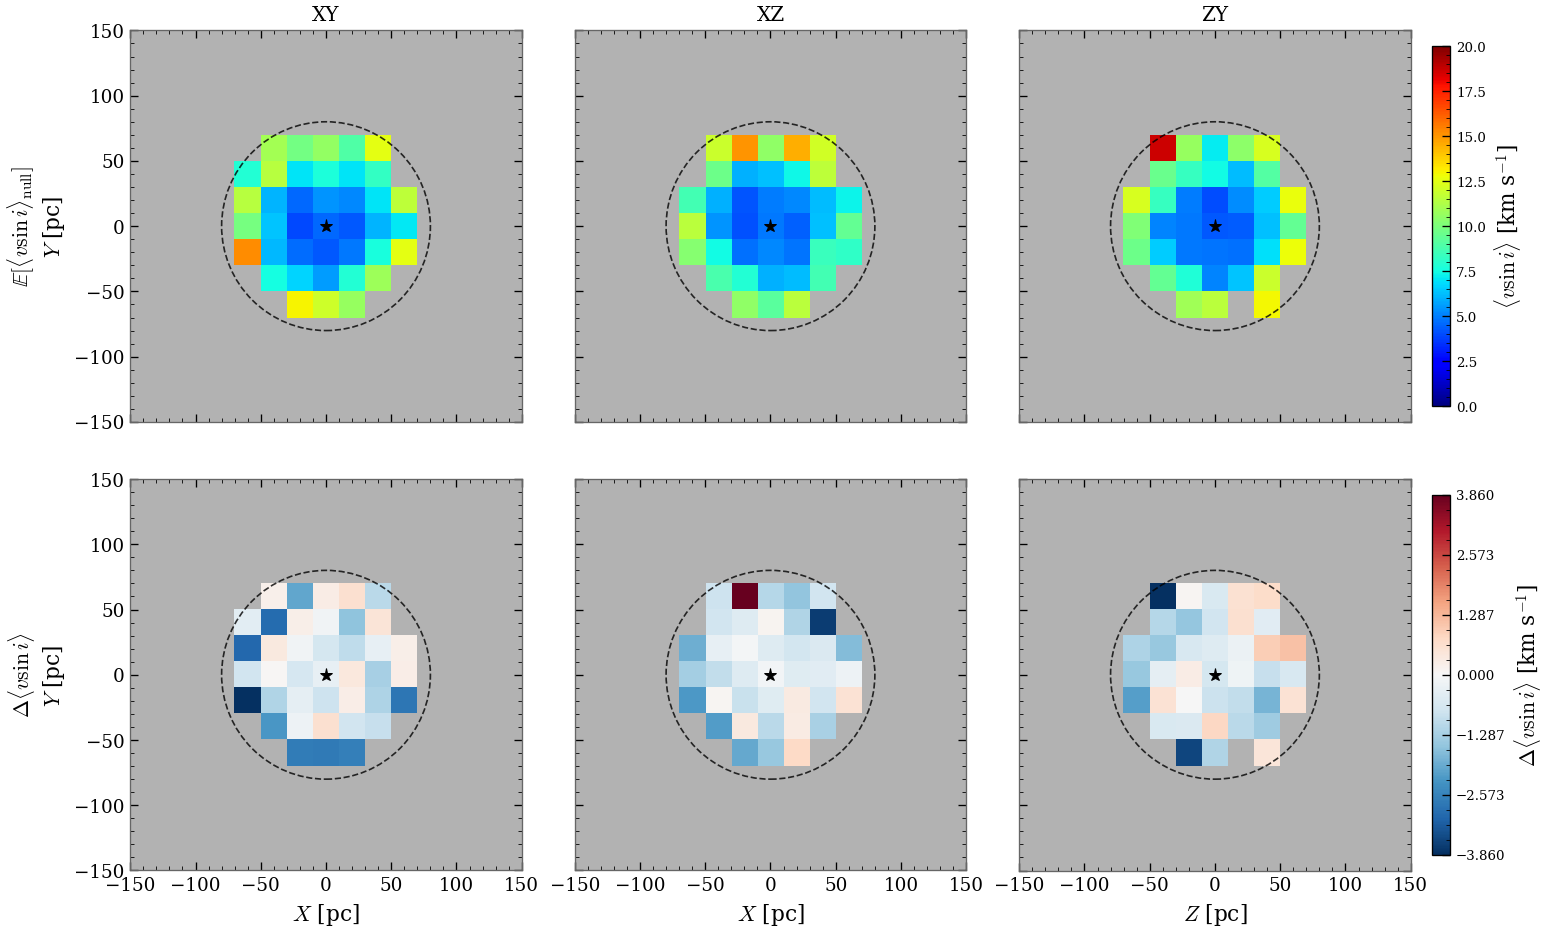

In [22]:
fig_res_dec, axes_res_decl = plot_residual_decomposition(
    residual_maps_all,
    # three_rows=True,
    ul=150.0,
    r_cut=R_CUT,
    vsini_cmap="jet",
    view_limit=150,
    tick_step=50,
    raw_cells=True,
    nan_color='0.7',
    clim = 3.86
)
# fig_res_dec.savefig(FIG_DIR / "null_residual_decomposition.pdf")
plt.show()

In [23]:
plot_residual_decomposition

<function src.plotting_p10.plot_residual_decomposition(residual_results: dict, three_rows: bool = False, ul: float = 150.0, r_cut: float = 80.0, planes: tuple = ('XY', 'XZ', 'ZY'), vsini_cmap: str = 'viridis', residual_cmap: str = 'RdBu_r', vsini_vmin: float = 0.0, vsini_vmax: float = 20.0, clim: float | None = None, nan_color: str = '0.95', raw_cells: bool = True, view_limit: float | None = 110.0, tick_step: float = 40.0, figsize: tuple | None = None) -> tuple>

## 7c. Per-star radial v sin i profile

Quantitative anchor for the transition-scale discussion in Sec. 3.2. Built from individual stellar radii, so it is independent of the 20 pc display grid (which only resolves out to the +/-70 pc cell edge). NOTE: the profile rises smoothly and monotonically -- 80 pc is a representative *contrast boundary*, not a sharp transition radius.

In [24]:
np.arange(0, 121, 5)

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120])

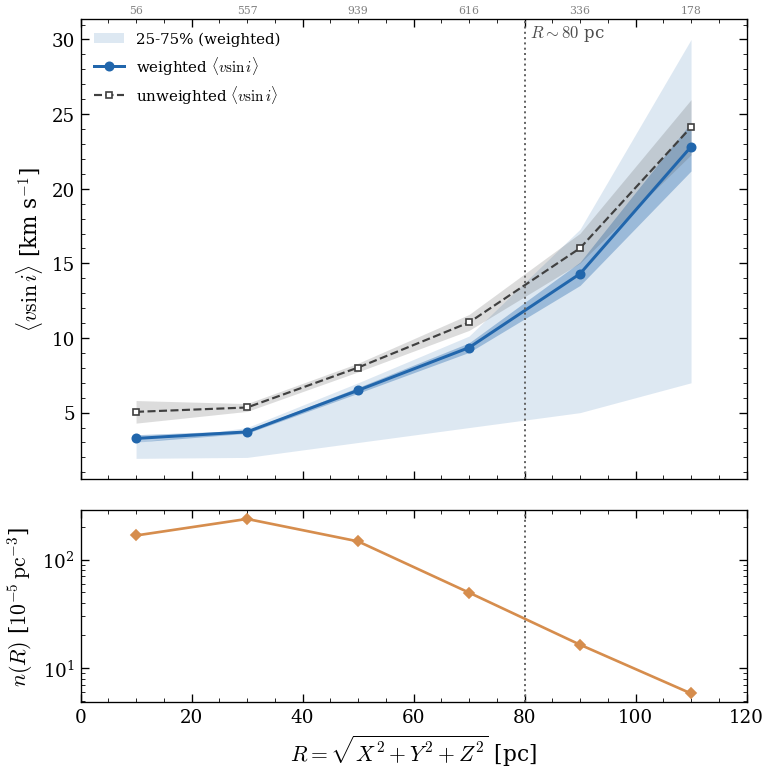

In [25]:
from src.plotting_p6 import plot_radial_profile

fig_rad, ax_rad, prof_rad = plot_radial_profile(
    df_all,
    radius="R3D",
    bin_edges=np.arange(0, 121, 20),
    r_cut=R_CUT,
    compare_weighting=True,
    show_density=True,
    n_bootstrap=1000,
    seed=SEED,
    show_unweighted_band = True
)
# fig_rad.savefig(FIG_DIR / "radial_vsini_profile.pdf", bbox_inches="tight")
plt.show()

## 8. Moran's I spatial autocorrelation

In [26]:
res_moran_all = morans_I(
    df_all,
    value_col="vsini",
    x_col="X",
    y_col="Y",
    k_neighbors=20,
    permutations=1000,
    seed=SEED,
)

print("--- Moran's I (vsini, all stars, XY) ---\n")
print(f"  I       = {res_moran_all['I']:.4f}")
print(f"  E[I]    = {res_moran_all['E_I']:.4f}")
print(f"  Z       = {res_moran_all['Z_I']:.2f}")
print(f"  p-value = {res_moran_all['p_value']:.4f}")

--- Moran's I (vsini, all stars, XY) ---

  I       = 0.1390
  E[I]    = -0.0004
  Z       = 24.37
  p-value = 0.0000


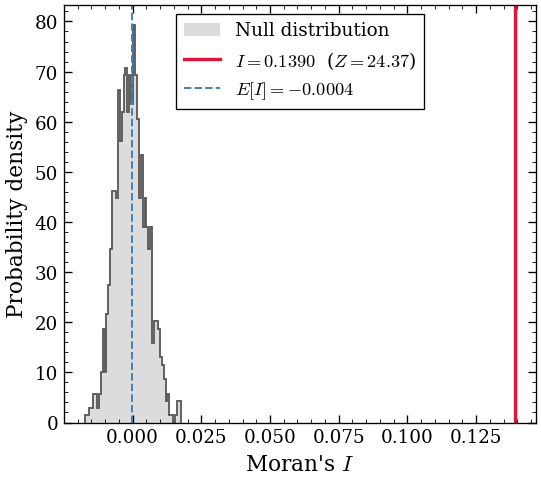

In [27]:
fig_moran, _ = plot_morans_I(res_moran_all, figsize=(4.5, 4))
# fig_moran.savefig(FIG_DIR / "morans_I_all.pdf")
plt.show()

## 9. Teff-residual Moran's I

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

sub = df_all[["vsini", "Teff", "X", "Y"]].dropna().copy()

scaler = StandardScaler()
X_sc = scaler.fit_transform(sub[["Teff"]].to_numpy())
reg = LinearRegression().fit(X_sc, sub["vsini"].to_numpy())
sub["vsini_resid"] = sub["vsini"] - reg.predict(X_sc)

res_moran_resid = morans_I(
    sub,
    value_col="vsini_resid",
    x_col="X",
    y_col="Y",
    k_neighbors=20,
    permutations=1000,
    seed=SEED,
)

print("--- Moran's I (Teff-detrended residuals) ---\n")
print(f"  I       = {res_moran_resid['I']:.4f}")
print(f"  Z       = {res_moran_resid['Z_I']:.2f}")
print(f"  p-value = {res_moran_resid['p_value']:.4f}")

--- Moran's I (Teff-detrended residuals) ---

  I       = 0.0564
  Z       = 9.84
  p-value = 0.0000


## 10. vsini vs. distance

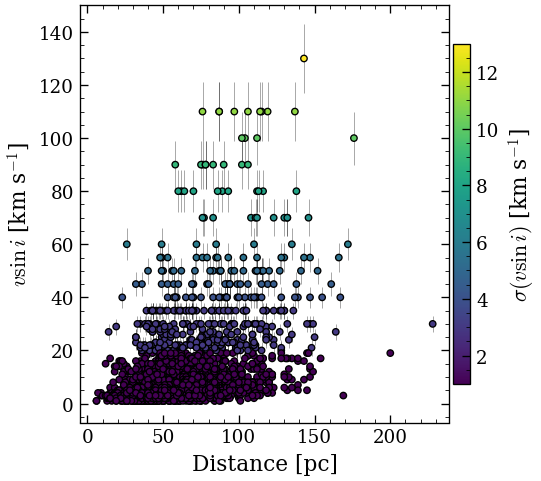

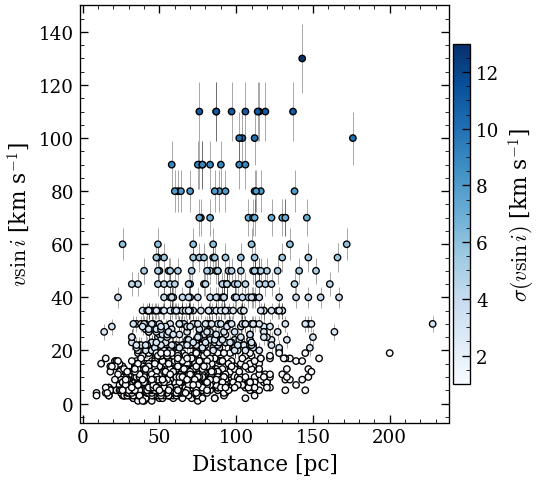

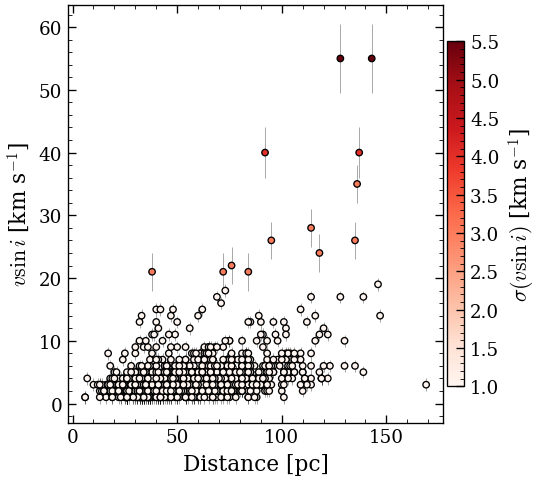

In [29]:
for df, label, cmap in [
    (df_all, "All stars", "viridis"),
    (df_F, "F-type", "Blues"),
    (df_G, "G-type", "Reds"),
]:
    fig, _ = plot_vsini_distance(df, cmap=cmap, figsize=(4.5, 4))
    # fig.savefig(FIG_DIR / f"fig_vsini_dist_{label.lower().replace(' ', '_')}.pdf")
    plt.show()

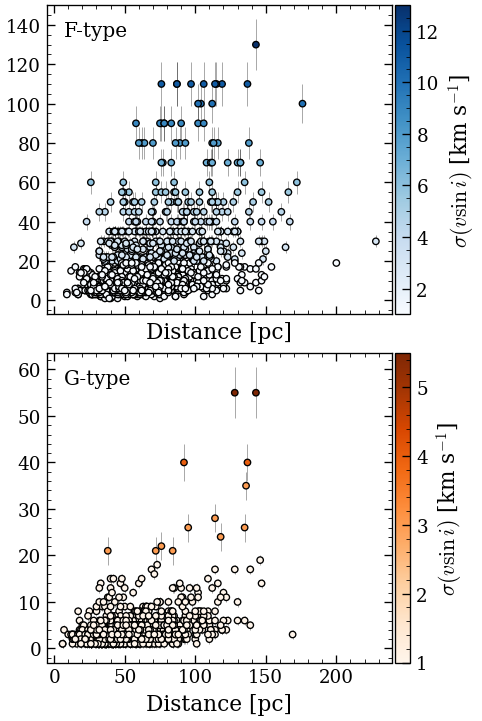

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(4, 6), sharex=True)

plot_vsini_distance(df_F,
                    cmap="Blues",
                    ax=axes[0],
                    )
plot_vsini_distance(df_G,
                    cmap="Oranges",
                    ax=axes[1],
                    )

axes[0].set_ylabel("")
axes[1].set_ylabel("")

axes[0].text(0.05, 0.9, "F-type", transform=axes[0].transAxes)
axes[1].text(0.05, 0.9, "G-type", transform=axes[1].transAxes)

# fig.savefig(FIG_DIR / "fig_vsini_dist_F_G.pdf")
plt.show()

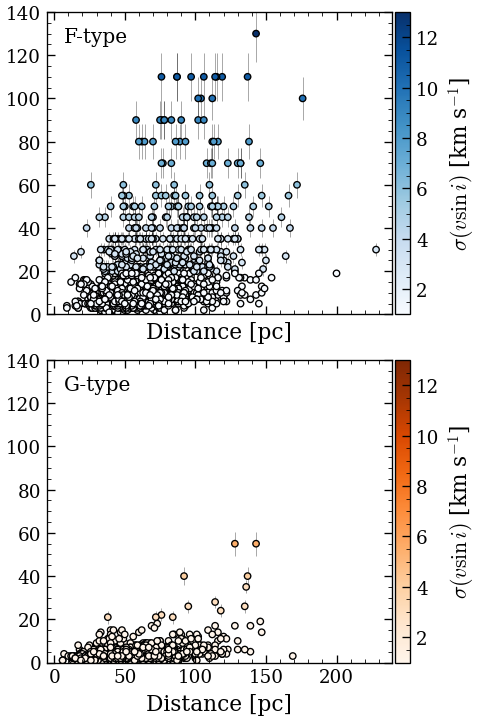

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(4, 6), sharex=True)

# Minor Comment 1: match y-axis range and color scale across both panels
# so the contrast between the F- and G-type samples is directly comparable.
# Shared limits span the combined data range (vsini up to 130 km/s in F;
# sigma from 1 to 13 km/s set by the F-type fast rotators).
shared_ylim = (0, 140)
shared_vmin, shared_vmax = 1.0, 13.0

plot_vsini_distance(
    df_F, cmap="Blues", ax=axes[0],
    ylim=shared_ylim, vmin=shared_vmin, vmax=shared_vmax,
)
plot_vsini_distance(
    df_G, cmap="Oranges", ax=axes[1],
    ylim=shared_ylim, vmin=shared_vmin, vmax=shared_vmax,
)

axes[0].set_ylabel("")
axes[1].set_ylabel("")

axes[0].text(0.05, 0.9, "F-type", transform=axes[0].transAxes)
axes[1].text(0.05, 0.9, "G-type", transform=axes[1].transAxes)

fig.savefig(FIG_DIR / "fig_vsini_dist_F_G.pdf")
plt.show()